# Input and output formats

`sfsutils` reads variants from a VCF file, a VCF-Zarr store, or a tskit tree sequence through a single streamed site interface, so the same analysis code works for any input format. Writing follows the output file's extension.

The dataset here is one synthetic ARG, provided as a tree sequence together with the VCF and VCF-Zarr store converted from it. Since all three encode the same genotypes, they yield the same spectrum.

In [1]:
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [4.4, 3.3]

In [2]:
import os, tempfile, shutil
import numpy as np

_root = os.getcwd()
_resources = os.path.join(_root, 'resources', 'msprime')
_work = tempfile.mkdtemp()
for _name in ('two_epoch.trees', 'two_epoch.vcf'):
    shutil.copy(os.path.join(_resources, _name), _work)
shutil.copytree(os.path.join(_resources, 'two_epoch.vcz'), os.path.join(_work, 'two_epoch.vcz'))
os.chdir(_work)

## Three input forms

In [3]:
trees = 'two_epoch.trees'  # tskit tree sequence (the ARG)
vcf   = 'two_epoch.vcf'    # VCF written from it
vcz   = 'two_epoch.vcz'    # VCF-Zarr store converted from the VCF

## Reading

{class}`~sfsutils.parser.Parser` accepts any of the three as its `source` argument and infers the backend from the source. Reading a VCF-Zarr store needs the optional `zarr` package, a tree sequence the optional `tskit` package.

In [4]:
import sfsutils as su

kw = dict(n=10, skip_non_polarized=False)
sfs_trees = su.Parser(source=trees, **kw).parse()
sfs_vcf   = su.Parser(source=vcf,   **kw).parse()
sfs_vcz   = su.Parser(source=vcz,   **kw).parse()

INFO:Parser: Using stratification: [all].
Parser>Processing sites: 100%|██████████| 608/608 [00:00<00:00, 20697.82it/s]
INFO:PolyAllelicFiltration: Filtered out 0 sites.
INFO:Parser: Included 608 out of 608 sites in total from the input.
INFO:Parser: Using stratification: [all].
INFO:Parser: Loading VCF file
Parser>Counting sites: 608it [00:00, 3576629.50it/s]
Parser>Processing sites: 100%|██████████| 608/608 [00:00<00:00, 24473.72it/s]
INFO:PolyAllelicFiltration: Filtered out 0 sites.
INFO:Parser: Included 608 out of 608 sites in total from the input.
INFO:Parser: Using stratification: [all].
Parser>Processing sites: 100%|██████████| 608/608 [00:00<00:00, 25442.60it/s]
INFO:PolyAllelicFiltration: Filtered out 0 sites.
INFO:Parser: Included 608 out of 608 sites in total from the input.


In [5]:
# the three spectra are identical
np.allclose(sfs_trees.all.to_list(), sfs_vcf.all.to_list()) and \
    np.allclose(sfs_vcf.all.to_list(), sfs_vcz.all.to_list())

True

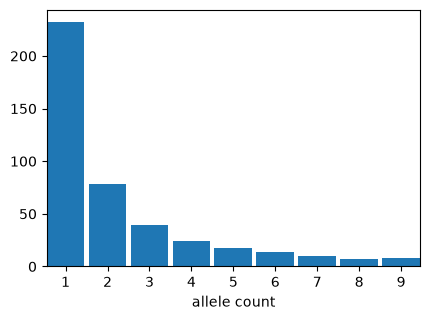

In [6]:
sfs_vcf.all.plot();

## Writing

{class}`~sfsutils.filtration.Filterer` and {class}`~sfsutils.annotation.Annotator` pick the writer from the output file's extension: `.vcf`/`.vcf.gz` for a VCF, `.vcz`/`.zarr` for a VCF-Zarr store, and `.trees` for a tree sequence. A tree sequence can only be written from a tree-sequence input: filtering removes the discarded sites with `delete_sites`, leaving the genealogy intact. A genealogy cannot be reconstructed from genotype data, so writing a `.trees` from a VCF or VCF-Zarr store is rejected.

In [7]:
# a VCF-Zarr store can be written from any input
su.Filterer(source=vcf, output='snps.vcz', filtrations=[su.SNPFiltration()]).filter()

# a VCF is written from a VCF input as before
su.Filterer(source=vcf, output='snps.vcf', filtrations=[su.SNPFiltration()]).filter()

# a tree sequence is written from a tree-sequence input
su.Filterer(source=trees, output='snps.trees', filtrations=[su.SNPFiltration()]).filter()

INFO:Filterer: Start filtering
INFO:Filterer: Loading VCF file
Filterer>Counting sites: 608it [00:00, 3783585.80it/s]
Filterer>Processing sites: 100%|██████████| 608/608 [00:00<00:00, 109527.85it/s]
INFO:SNPFiltration: Filtered out 0 sites.
INFO:Filterer: Filtered out 0 of 608 sites in total.
INFO:Filterer: Start filtering
INFO:Filterer: Loading VCF file
Filterer>Counting sites: 608it [00:00, 3576629.50it/s]
Filterer>Processing sites: 100%|██████████| 608/608 [00:00<00:00, 302041.55it/s]
INFO:SNPFiltration: Filtered out 0 sites.
INFO:Filterer: Filtered out 0 of 608 sites in total.
INFO:Filterer: Start filtering
Filterer>Processing sites: 100%|██████████| 608/608 [00:00<00:00, 101264.22it/s]
INFO:SNPFiltration: Filtered out 0 sites.
INFO:Filterer: Filtered out 0 of 608 sites in total.


The store and tree sequence written above parse back to the same spectrum as the VCF output.

In [8]:
back = {f: su.Parser(source=f, **kw).parse().all.to_list() for f in ('snps.vcf', 'snps.vcz', 'snps.trees')}
all(np.allclose(v, back['snps.vcf']) for v in back.values())

INFO:Parser: Using stratification: [all].
INFO:Parser: Loading VCF file
Parser>Counting sites: 608it [00:00, 2276907.89it/s]
Parser>Processing sites: 100%|██████████| 608/608 [00:00<00:00, 25091.87it/s]
INFO:PolyAllelicFiltration: Filtered out 0 sites.
INFO:Parser: Included 608 out of 608 sites in total from the input.
INFO:Parser: Using stratification: [all].
Parser>Processing sites: 100%|██████████| 608/608 [00:00<00:00, 25626.94it/s]
INFO:PolyAllelicFiltration: Filtered out 0 sites.
INFO:Parser: Included 608 out of 608 sites in total from the input.
INFO:Parser: Using stratification: [all].
Parser>Processing sites: 100%|██████████| 608/608 [00:00<00:00, 21419.64it/s]
INFO:PolyAllelicFiltration: Filtered out 0 sites.
INFO:Parser: Included 608 out of 608 sites in total from the input.


True

In [9]:
os.chdir(_root)
shutil.rmtree(_work, ignore_errors=True)